In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import skccm
from skccm import Embed
from skccm import CCM
from skccm.utilities import train_test_split

In [2]:
infections = pd.read_csv("Data/Moving_Avg.csv")
infections["date"] = pd.to_datetime(infections["date"])

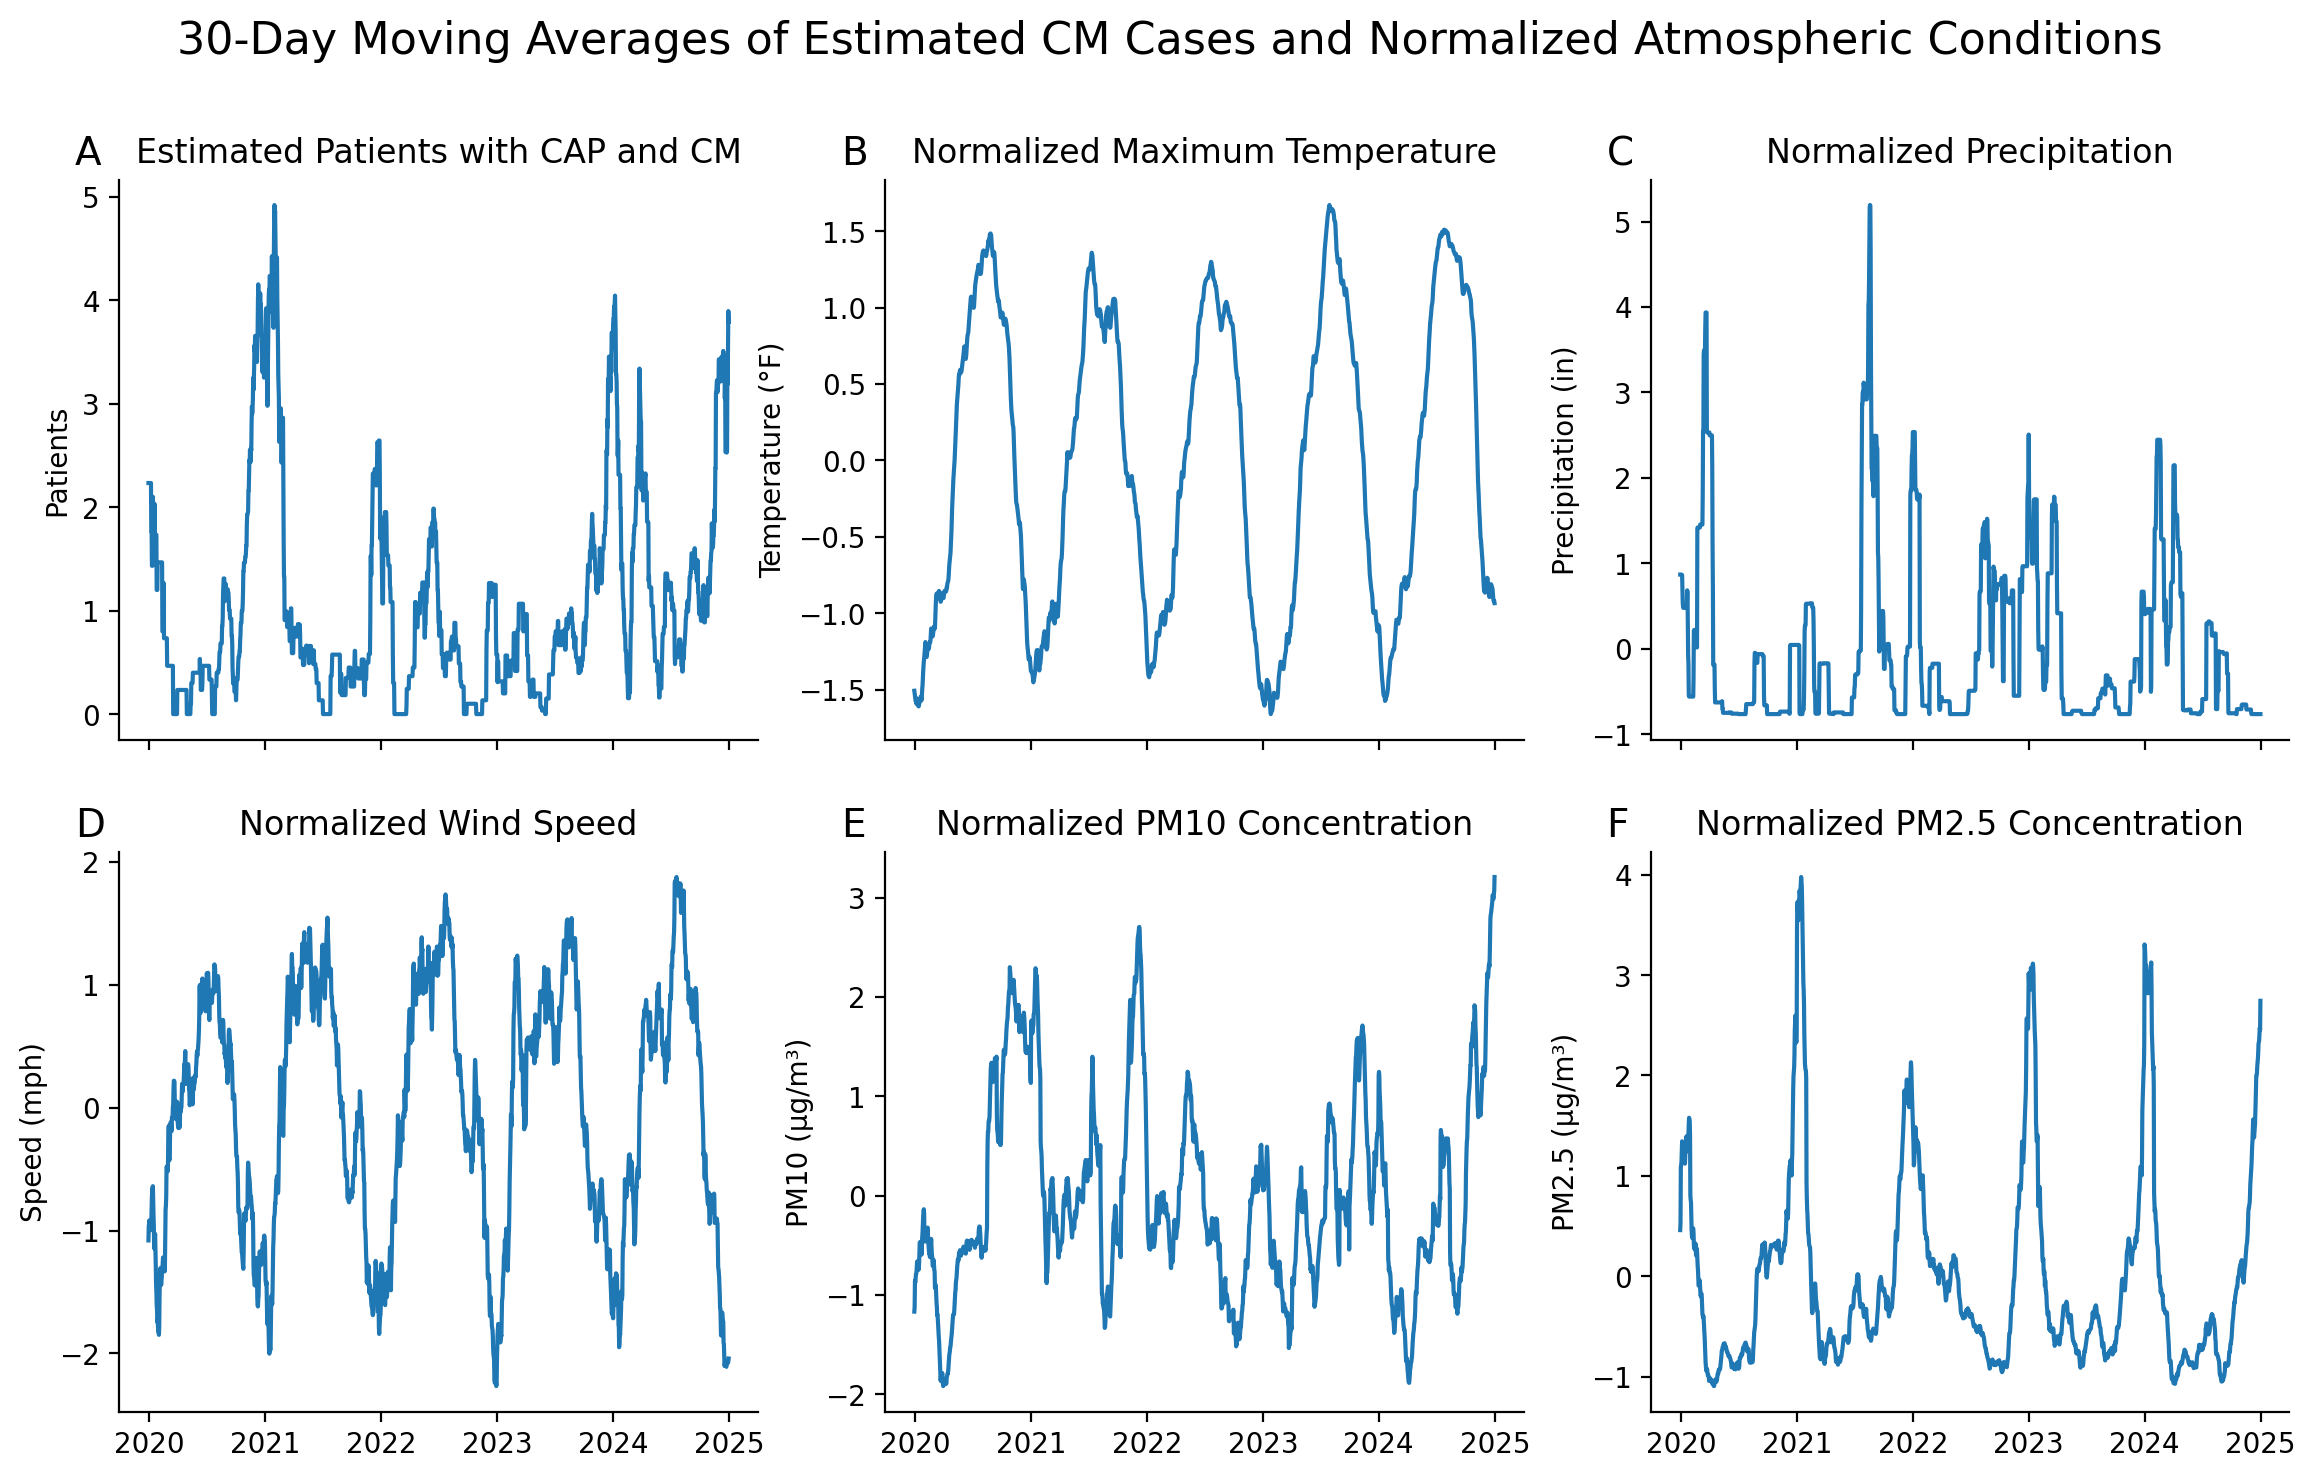

In [25]:
fig, axes = plt.subplots(2, 3, figsize = (14, 8), sharex = True)
ax1, ax2, ax3 = axes[0]
ax4, ax5, ax6 = axes[1]
fig.suptitle("30-Day Moving Averages of Estimated CM Cases and Normalized Atmospheric Conditions", fontsize = 16)

ax1.plot(infections["date"], infections["estpos"])
ax1.set_title("Estimated Patients with CAP and CM")
ax1.text(-0.07, 1.08, "A", transform = ax1.transAxes, va = "top", fontsize = 14)
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_ylabel("Patients")

ax2.plot(infections["date"], infections["maxtemp"])
ax2.set_title("Normalized Maximum Temperature")
ax2.text(-0.07, 1.08, "B", transform = ax2.transAxes, va = "top", fontsize = 14)
ax2.spines[["top", "right"]].set_visible(False)
ax2.set_ylabel("Temperature (°F)")

ax3.plot(infections["date"], infections["precip"])
ax3.set_title("Normalized Precipitation")
ax3.text(-0.07, 1.08, "C", transform = ax3.transAxes, va = "top", fontsize = 14)
ax3.spines[["top", "right"]].set_visible(False)
ax3.set_ylabel("Precipitation (in)")

ax4.plot(infections["date"], infections["wind"])
ax4.set_title("Normalized Wind Speed")
ax4.text(-0.07, 1.08, "D", transform = ax4.transAxes, va = "top", fontsize = 14)
ax4.spines[["top", "right"]].set_visible(False)
ax4.set_ylabel("Speed (mph)")

ax5.plot(infections["date"], infections["pm10"])
ax5.set_title("Normalized PM10 Concentration")
ax5.text(-0.07, 1.08, "E", transform = ax5.transAxes, va = "top", fontsize = 14)
ax5.spines[["top", "right"]].set_visible(False)
ax5.set_ylabel("PM10 (µg/m³)")

ax6.plot(infections["date"], infections["pm2.5"])
ax6.set_title("Normalized PM2.5 Concentration")
ax6.text(-0.07, 1.08, "F", transform = ax6.transAxes, va = "top", fontsize = 14)
ax6.spines[["top", "right"]].set_visible(False)
ax6.set_ylabel("PM2.5 (µg/m³)")

%config InlineBackend.figure_format = "retina"

# plt.savefig("ma_time_series.png", format = "png", dpi = 300, bbox_inches = "tight")

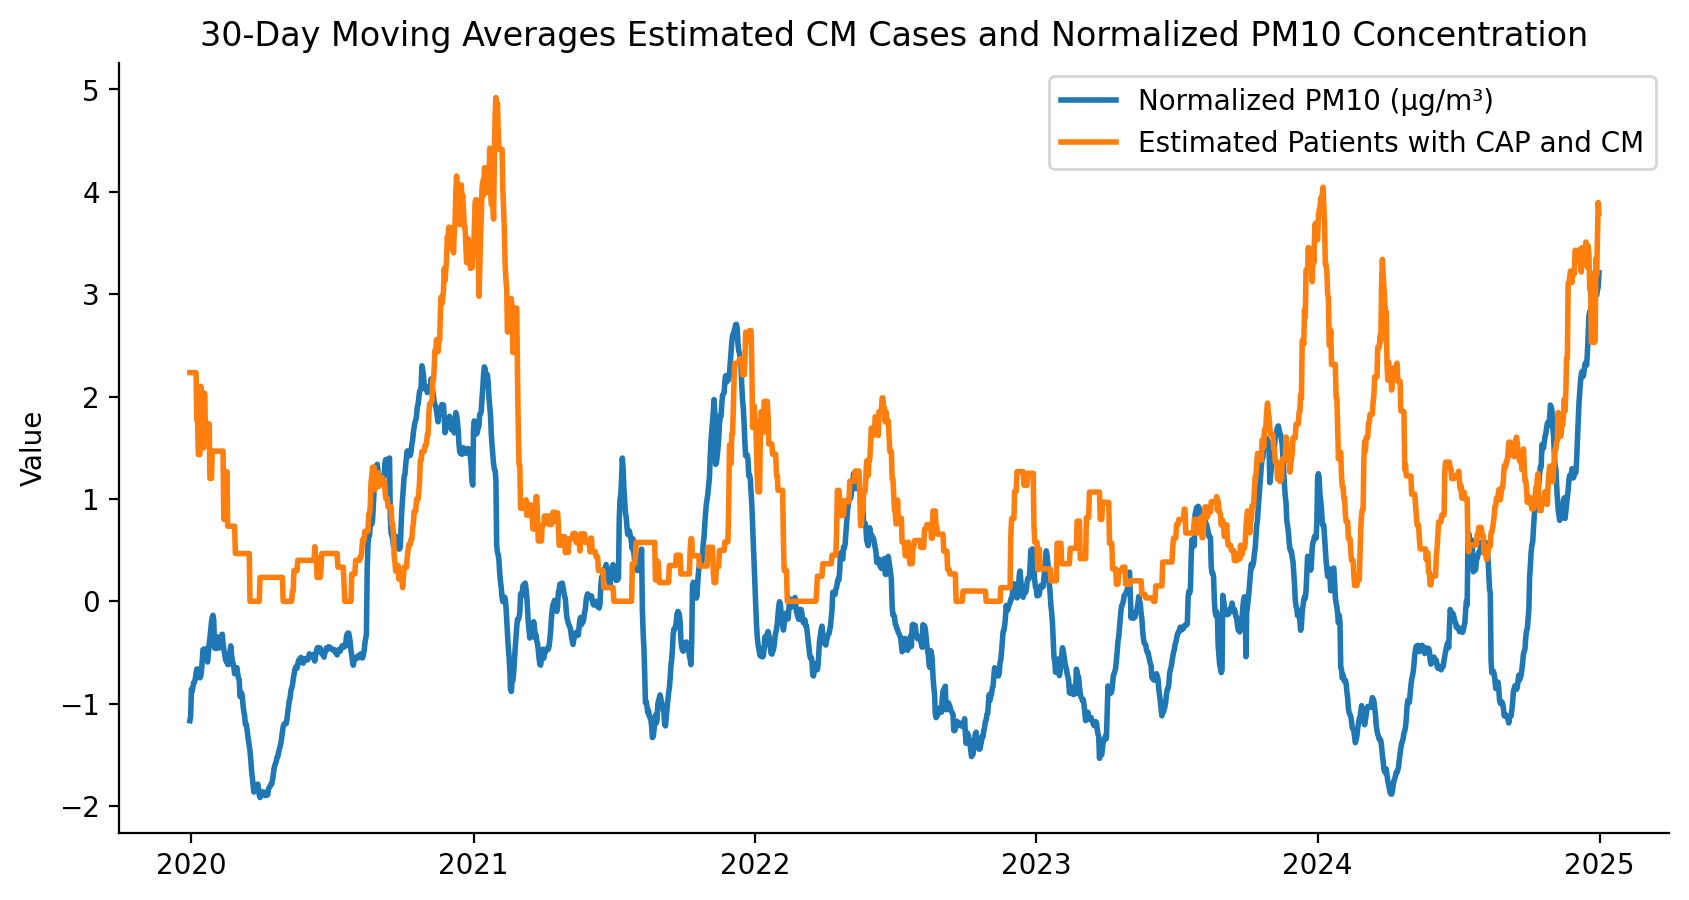

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(infections["date"], infections["pm10"], linewidth=2,
         label = "Normalized PM10 (µg/m³)")
plt.plot(infections["date"], infections["estpos"], linewidth=2,
         label = "Estimated Patients with CAP and CM")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.ylabel("Value")
plt.title("30-Day Moving Averages Estimated CM Cases and Normalized PM10 Concentration")
plt.legend()

%config InlineBackend.figure_format = "retina"

# plt.savefig("pm10_ma_time_series.png", format = "png", dpi = 300, bbox_inches = "tight")

In [14]:
params = ["maxtemp", "precip", "wind", "pm10", "pm2.5"]

outputs = {"param": [],
           "pearson": [],
           "param_predict_pos": [],
           "pos_predict_param": []}

for p in params:
    col_1 = p
    col_2 = "estpos"

    rho = infections[col_1].corr(infections[col_2])

    lag = 1
    embed = 2

    x1 = infections[col_1].values
    x2 = infections[col_2].values

    e1 = Embed(x1)
    e2 = Embed(x2)
    X1_embedded = e1.embed_vectors_1d(lag, embed)
    X2_embedded = e2.embed_vectors_1d(lag, embed)

    x1_tr, x1_te, x2_tr, x2_te = X1_embedded, X1_embedded, X2_embedded, X2_embedded

    ccm = CCM()

    len_tr = len(x1_tr)
    lib_lens = np.arange(10, len_tr, 20, dtype = "int")

    ccm.fit(x1_tr, x2_tr)

    x1p, x2p = ccm.predict(x1_te, x2_te, lib_lengths=lib_lens)

    sc1, sc2 = ccm.score()

    outputs["param"].append(p)
    outputs["pearson"].append(rho)
    outputs["param_predict_pos"].append(sc2[-1])
    outputs["pos_predict_param"].append(sc1[-1])

outputs = pd.DataFrame.from_dict(outputs)
outputs

,param,pearson,param_predict_pos,pos_predict_param
0,maxtemp,-0.389164,0.976364,0.844493
1,precip,-0.047222,0.816865,0.600755
2,wind,-0.495821,0.986927,0.875004
3,pm10,0.472373,0.995259,0.901528
4,pm2.5,0.582746,0.992594,0.932890
